# 🚖 Uber Fare Prediction using Machine Learning

### 📌 Project Overview

This project predicts the fare amount for Uber rides using Machine Learning techniques. The model estimates the fare based on trip-related features such as pickup and dropoff locations, passenger count, and the distance travelled.

The project includes:

- Data Cleaning and Preprocessing
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Machine Learning Model Development
- Model Evaluation
- Model Persistence
- Deployment using Streamlit

---

### 👨‍💻 Author

**Harsh Gopinath Chavan**

---

### 🎯 Objective

Build a production-ready Machine Learning application capable of predicting Uber ride fares accurately and deploy it through an interactive Streamlit web application.

## 📚 1. Import Required Libraries

In this section, we import all the libraries required for data manipulation, visualization, feature engineering, machine learning, and model evaluation.

In [3]:
# Suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 📂 2. Load the Dataset

Load the Uber Fare Prediction dataset and perform an initial inspection to understand its structure, size, and available features.

In [9]:
# Load the dataset
df = pd.read_csv("../data/uber.csv")

In [10]:
# Display the first five rows
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [11]:
# Display the number of rows and columns
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (200000, 9)


In [12]:
# Display all feature names
df.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [13]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [14]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,200000.0,2.771250e+07,1.601382e+07,1.000000,1.382535e+07,2.774550e+07,4.155530e+07,5.542357e+07
fare_amount,200000.0,1.135996e+01,9.901776e+00,-52.000000,6.000000e+00,8.500000e+00,1.250000e+01,4.990000e+02
pickup_longitude,200000.0,-7.252764e+01,1.143779e+01,-1340.648410,-7.399206e+01,-7.398182e+01,-7.396715e+01,5.741846e+01
pickup_latitude,200000.0,3.993589e+01,7.720539e+00,-74.015515,4.073480e+01,4.075259e+01,4.076716e+01,1.644421e+03
dropoff_longitude,199999.0,-7.252529e+01,1.311741e+01,-3356.666300,-7.399141e+01,-7.398009e+01,-7.396366e+01,1.153573e+03
dropoff_latitude,199999.0,3.992389e+01,6.794829e+00,-881.985513,4.073382e+01,4.075304e+01,4.076800e+01,8.726976e+02
passenger_count,200000.0,1.684535e+00,1.385997e+00,0.000000,1.000000e+00,1.000000e+00,2.000000e+00,2.080000e+02


In [15]:
# Check for missing values
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

## 🧹 4. Data Cleaning

The quality of the dataset directly impacts the performance of machine learning models. In this section, we identify and handle missing values, duplicate records, incorrect data types, and other inconsistencies to prepare the data for feature engineering and model training.

In [16]:
# Check missing values
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [17]:
df.columns.tolist()

['Unnamed: 0',
 'key',
 'fare_amount',
 'pickup_datetime',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'passenger_count']

In [18]:
# Remove unnecessary columns
df.drop(columns=["Unnamed: 0", "key"], inplace=True, errors="ignore")

# Remove rows with missing values
df.dropna(inplace=True)

# Convert pickup_datetime to datetime format
df["pickup_datetime"] = pd.to_datetime(
    df["pickup_datetime"],
    errors="coerce"
)

# Remove rows where datetime conversion failed
df.dropna(subset=["pickup_datetime"], inplace=True)

# Extract useful datetime features
df["year"] = df["pickup_datetime"].dt.year
df["month"] = df["pickup_datetime"].dt.month
df["day"] = df["pickup_datetime"].dt.day
df["hour"] = df["pickup_datetime"].dt.hour
df["day_of_week"] = df["pickup_datetime"].dt.dayofweek

# Keep only valid geographic coordinates
df = df[
    df["pickup_latitude"].between(-90, 90)
    & df["dropoff_latitude"].between(-90, 90)
    & df["pickup_longitude"].between(-180, 180)
    & df["dropoff_longitude"].between(-180, 180)
]

# Remove invalid fare amounts and passenger counts
df = df[
    (df["fare_amount"] > 0)
    & (df["passenger_count"] > 0)
]

# Reset the index after preprocessing
df.reset_index(drop=True, inplace=True)

print(f"Dataset Shape after Preprocessing: {df.shape}")

df.head()

Dataset Shape after Preprocessing: (199257, 12)


,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,day_of_week
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3


In [19]:
df.columns.tolist()

['fare_amount',
 'pickup_datetime',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'passenger_count',
 'year',
 'month',
 'day',
 'hour',
 'day_of_week']

## 🗺️ 4. Feature Engineering

Feature engineering is the process of creating new features from existing data to improve model performance.

For fare prediction, the straight-line distance between the pickup and dropoff locations is one of the most important factors influencing the fare. This distance is calculated using the **Haversine Formula**, which computes the shortest distance between two points on the Earth's surface.

In [20]:
from math import radians, sin, cos, sqrt, atan2

# Function to calculate the great-circle distance
# between two geographic coordinates using the Haversine formula.
def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate the distance between two latitude-longitude points.

    Returns:
        Distance in kilometers.
    """

    R = 6371  # Earth's radius in kilometers

    lat1, lon1, lat2, lon2 = map(
        radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1)
        * cos(lat2)
        * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c


# Create distance feature
df["distance_km"] = df.apply(
    lambda row: haversine(
        row["pickup_latitude"],
        row["pickup_longitude"],
        row["dropoff_latitude"],
        row["dropoff_longitude"]
    ),
    axis=1
)

# Remove records with unrealistic distance
df = df[
    (df["distance_km"] > 0)
    & (df["distance_km"] <= 100)
]

df.reset_index(drop=True, inplace=True)


df.reset_index(drop=True, inplace=True)

# Display the engineered feature
df[["fare_amount", "distance_km"]].head()

,fare_amount,distance_km
0,7.5,1.683323
1,7.7,2.457590
2,12.9,5.036377
3,5.3,1.661683
4,16.0,4.475450


In [21]:
print(df[["fare_amount", "distance_km"]].corr())

             fare_amount  distance_km
fare_amount     1.000000     0.841155
distance_km     0.841155     1.000000


## 📈 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps uncover patterns, relationships, and anomalies within the dataset. Understanding these insights is essential before training machine learning models.

In this section, we analyze the distribution of fares, passenger counts, travel distances, and the relationships between important features.

In [22]:
# Display dataset information after feature engineering
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193192 entries, 0 to 193191
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   fare_amount        193192 non-null  float64            
 1   pickup_datetime    193192 non-null  datetime64[ns, UTC]
 2   pickup_longitude   193192 non-null  float64            
 3   pickup_latitude    193192 non-null  float64            
 4   dropoff_longitude  193192 non-null  float64            
 5   dropoff_latitude   193192 non-null  float64            
 6   passenger_count    193192 non-null  int64              
 7   year               193192 non-null  int32              
 8   month              193192 non-null  int32              
 9   day                193192 non-null  int32              
 10  hour               193192 non-null  int32              
 11  day_of_week        193192 non-null  int32              
 12  distance_km        193192 non-

In [23]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fare_amount,193192.0,11.354572,9.740375,0.010000,6.000000,8.500000,12.500000,499.000000
pickup_longitude,193192.0,-73.910367,2.689796,-75.387785,-73.992279,-73.982130,-73.968460,40.808425
pickup_latitude,193192.0,40.688309,2.633983,-74.015515,40.736438,40.753283,40.767528,45.031653
dropoff_longitude,193192.0,-73.909400,2.689884,-75.417737,-73.991600,-73.980568,-73.965517,40.831932
dropoff_latitude,193192.0,40.688616,2.634309,-74.015750,40.735312,40.753734,40.768323,45.031598
passenger_count,193192.0,1.690934,1.387377,1.000000,1.000000,1.000000,2.000000,208.000000
year,193192.0,2011.746527,1.862916,2009.000000,2010.000000,2012.000000,2013.000000,2015.000000
month,193192.0,6.283283,3.440087,1.000000,3.000000,6.000000,9.000000,12.000000
day,193192.0,15.705687,8.687227,1.000000,8.000000,16.000000,23.000000,31.000000
hour,193192.0,13.488840,6.516369,0.000000,9.000000,14.000000,19.000000,23.000000


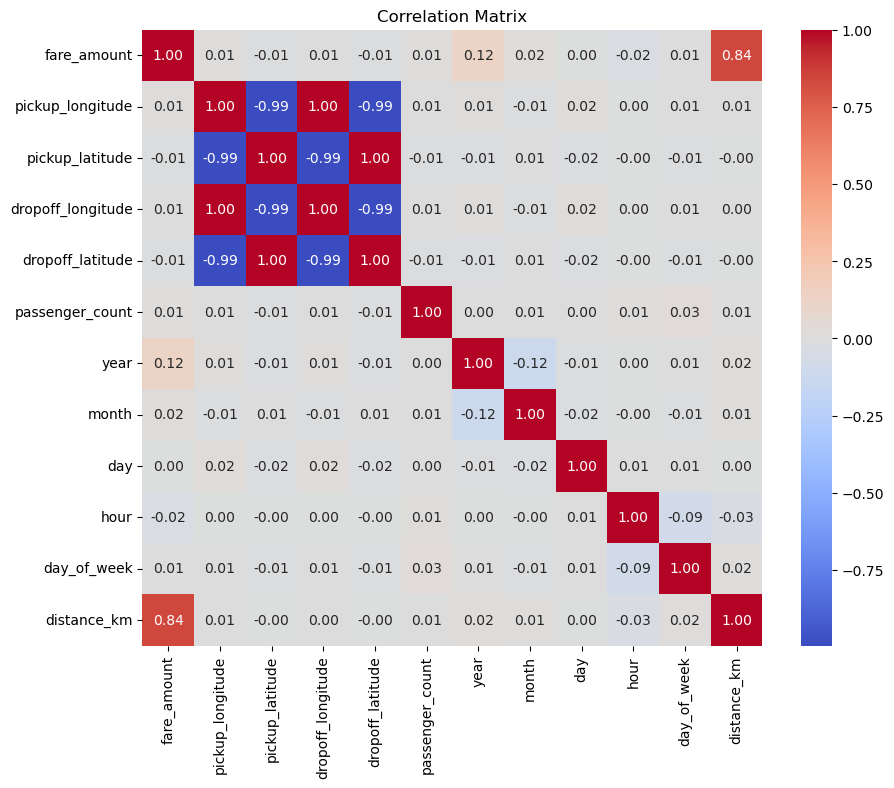

In [24]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

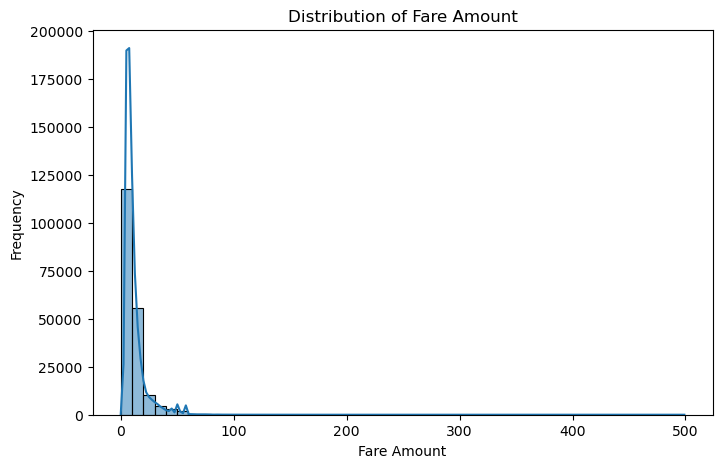

In [25]:
# Fare Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["fare_amount"], bins=50, kde=True)

plt.title("Distribution of Fare Amount")
plt.xlabel("Fare Amount")
plt.ylabel("Frequency")

plt.show()

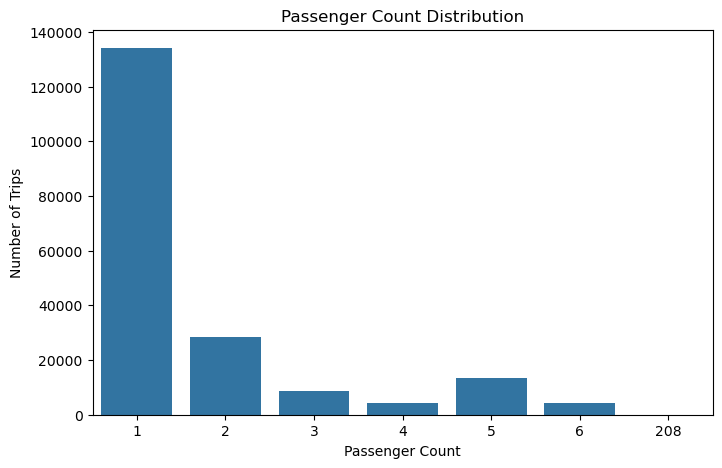

In [26]:
# Passenger Count Distribution
plt.figure(figsize=(8,5))

sns.countplot(x=df["passenger_count"])

plt.title("Passenger Count Distribution")
plt.xlabel("Passenger Count")
plt.ylabel("Number of Trips")

plt.show()

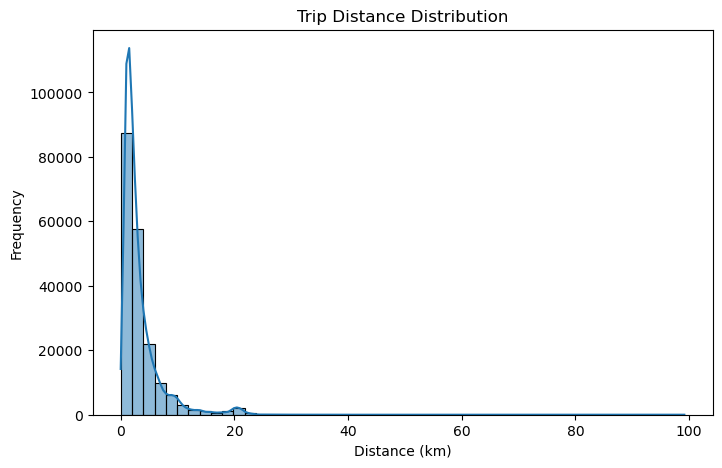

In [27]:
# Distance Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["distance_km"], bins=50, kde=True)

plt.title("Trip Distance Distribution")
plt.xlabel("Distance (km)")
plt.ylabel("Frequency")

plt.show()

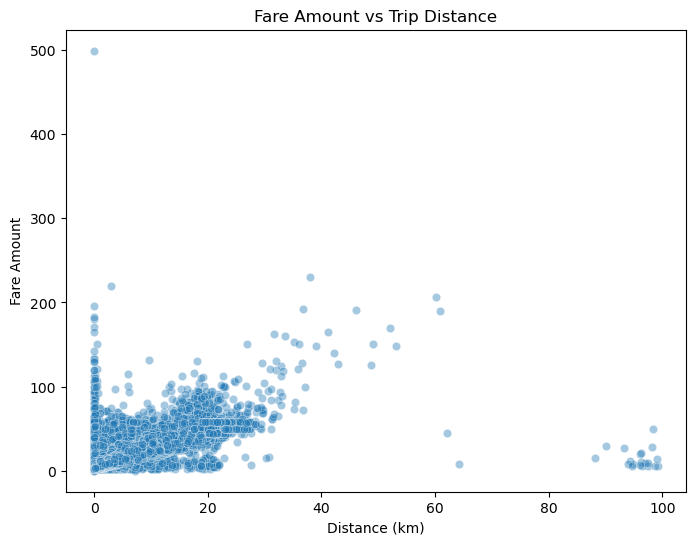

In [28]:
# Fare vs Distance
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="distance_km",
    y="fare_amount",
    data=df,
    alpha=0.4
)

plt.title("Fare Amount vs Trip Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Fare Amount")

plt.show()

## 📊 5.1 Outlier Detection and Correlation Analysis

Outliers can negatively impact the performance of machine learning models by introducing noise and skewing the data distribution. In this section, the Interquartile Range (IQR) method is used to identify and remove extreme fare values.

After cleaning the data, a correlation heatmap is generated to understand the relationships between the numerical features.

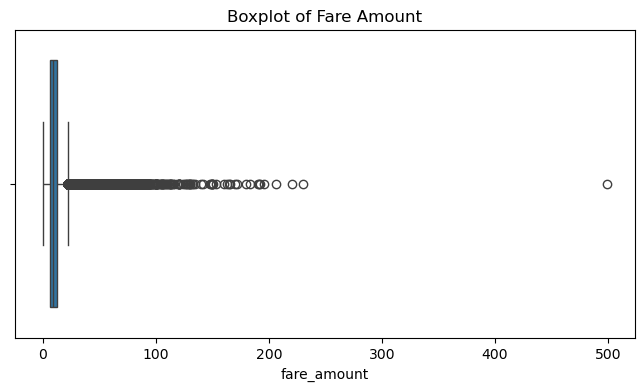

Before Removing Outliers : (193192, 13)
After Removing Outliers  : (176652, 13)
Outliers Removed: 16540 rows


In [29]:
# Boxplot before removing outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["fare_amount"])
plt.title("Boxplot of Fare Amount")
plt.show()

# Store original shape
before_shape = df.shape

# Calculate IQR
Q1 = df["fare_amount"].quantile(0.25)
Q3 = df["fare_amount"].quantile(0.75)
IQR = Q3 - Q1

# Remove outliers
df = df[
    (df["fare_amount"] >= Q1 - 1.5 * IQR) &
    (df["fare_amount"] <= Q3 + 1.5 * IQR)
]

df.reset_index(drop=True, inplace=True)

# Compare dataset size
print("Before Removing Outliers :", before_shape)
print("After Removing Outliers  :", df.shape)
print(f"Outliers Removed: {before_shape[0] - df.shape[0]} rows")

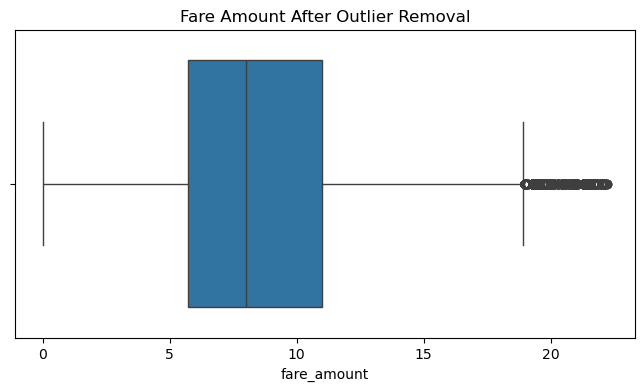

In [30]:
# Boxplot after removing outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["fare_amount"])
plt.title("Fare Amount After Outlier Removal")
plt.show()

In [31]:
# CORRELATION ANALYSIS

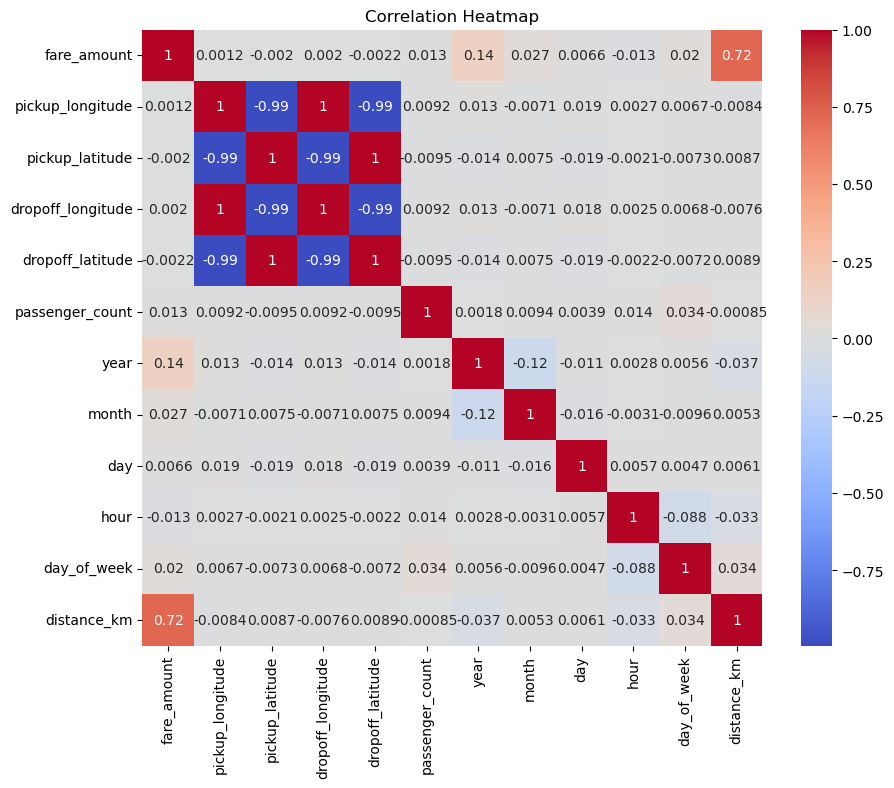

In [32]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 🤖 6. Model Development

After cleaning and preprocessing the dataset, the features are prepared for machine learning. The dataset is split into training and testing sets to evaluate the model's performance on unseen data.

Multiple regression models will be trained and compared to identify the best-performing model for Uber fare prediction.

In [33]:
# Select input features and target variable
X = df.drop(
    columns=[
        "fare_amount",
        "pickup_datetime"
    ]
)

y = df["fare_amount"]

X.head()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,day_of_week,distance_km
0,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,1.683323
1,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,2.457590
2,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,5.036377
3,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,1.661683
4,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,4.475450


In [34]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

Training Samples : 141321
Testing Samples  : 35331


### 📈 Linear Regression

Linear Regression serves as a baseline regression model for predicting Uber fares. It assumes a linear relationship between the input features and the target variable, providing a simple yet effective benchmark for comparing more advanced models.

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Initialize the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Generate predictions
lr_pred = lr_model.predict(X_test)

# Evaluate the model
lr_r2 = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)

# Display results
print("Linear Regression Performance")
print("-" * 35)
print(f"R² Score : {lr_r2:.4f}")
print(f"RMSE     : {lr_rmse:.4f}")
print(f"MAE      : {lr_mae:.4f}")

# Compare actual vs predicted fares
comparison = pd.DataFrame({
    "Actual Fare": y_test.values,
    "Predicted Fare": np.round(lr_pred, 2)
})

comparison.head(10)

Linear Regression Performance
-----------------------------------
R² Score : 0.6197
RMSE     : 2.5640
MAE      : 1.8122


,Actual Fare,Predicted Fare
0,5.3,6.14
1,4.0,7.12
2,10.5,8.25
3,5.0,6.79
4,3.7,5.74
5,18.0,15.75
6,6.1,7.07
7,4.9,6.67
8,4.5,7.36
9,7.3,8.94


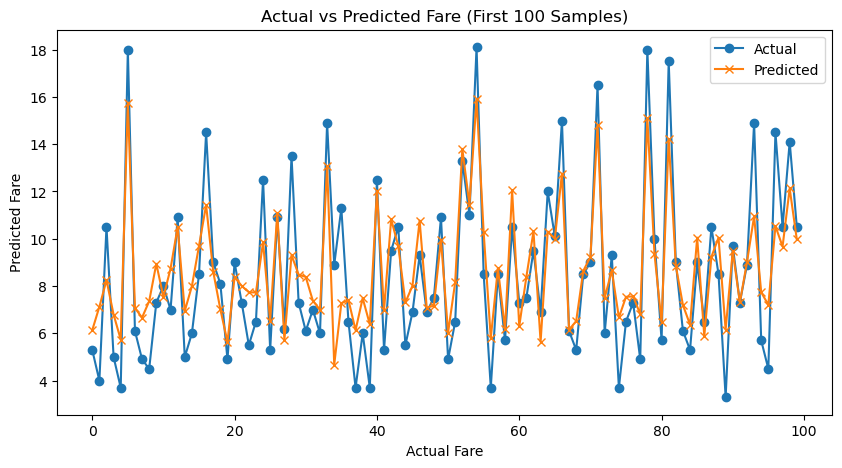

In [36]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Actual", marker='o')
plt.plot(lr_pred[:100], label="Predicted", marker='x')

plt.title("Actual vs Predicted Fare (First 100 Samples)")
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.legend()

plt.show()

### 🌲 Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is capable of capturing complex non-linear relationships between trip features and fare amounts.

In [37]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Generate predictions
rf_pred = rf_model.predict(X_test)

In [38]:
# Evaluate the model
rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)

# Display results
print("Random Forest Performance")
print("-" * 35)
print(f"R² Score : {rf_r2:.4f}")
print(f"RMSE     : {rf_rmse:.4f}")
print(f"MAE      : {rf_mae:.4f}")

Random Forest Performance
-----------------------------------
R² Score : 0.7850
RMSE     : 1.9277
MAE      : 1.3304


In [39]:
rf_comparison = pd.DataFrame({
    "Actual Fare": y_test.values,
    "Predicted Fare": np.round(rf_pred, 2)
})

rf_comparison.head(10)

,Actual Fare,Predicted Fare
0,5.3,5.93
1,4.0,5.74
2,10.5,10.48
3,5.0,5.11
4,3.7,4.57
5,18.0,17.65
6,6.1,7.33
7,4.9,5.88
8,4.5,6.90
9,7.3,7.96


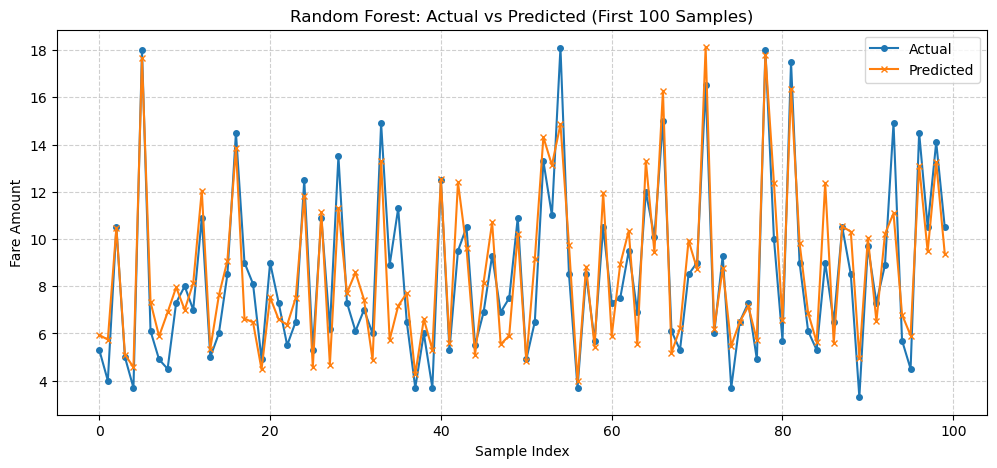

In [40]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:100],
    label="Actual",
    marker="o",
    markersize=4
)

plt.plot(
    rf_pred[:100],
    label="Predicted",
    marker="x",
    markersize=4
)

plt.title("Random Forest: Actual vs Predicted (First 100 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Fare Amount")

plt.legend()

plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

In [41]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R² Score": [lr_r2, rf_r2],
    "RMSE": [lr_rmse, rf_rmse],
    "MAE": [lr_mae, rf_mae]
})

results.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

,Model,R² Score,RMSE,MAE
0,Random Forest,0.785015,1.927717,1.330409
1,Linear Regression,0.619661,2.564041,1.812165


### 📌 Feature Importance

Random Forest provides feature importance scores that indicate how much each feature contributes to the prediction. Understanding these scores helps interpret the model and identify the most influential variables.

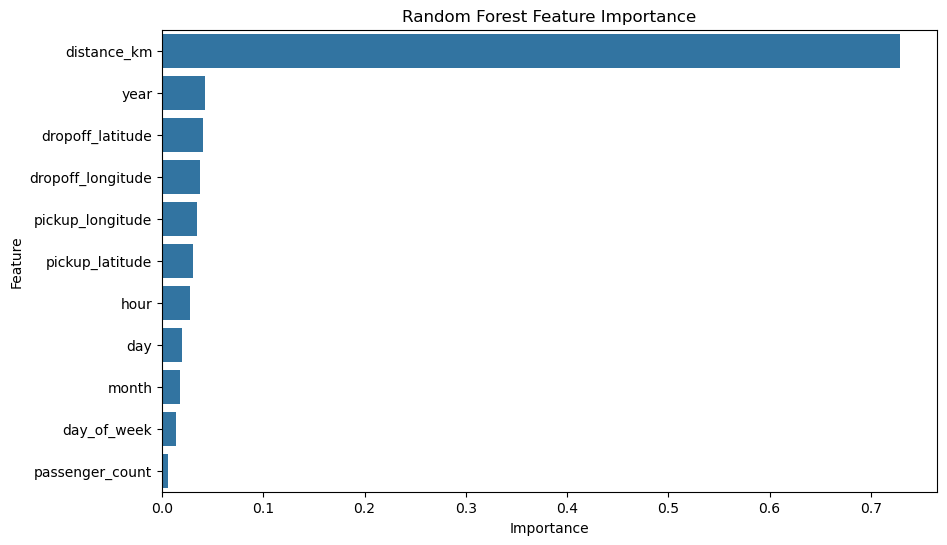

,Feature,Importance
10,distance_km,0.728991
5,year,0.042687
3,dropoff_latitude,0.040282
2,dropoff_longitude,0.037075
0,pickup_longitude,0.034186
1,pickup_latitude,0.030804
8,hour,0.027616
7,day,0.019819
6,month,0.018018
9,day_of_week,0.014148


In [42]:
# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

feature_importance

## 💾 7. Save the Best Model

The Random Forest model achieved the highest predictive performance and is selected as the final model. The trained model is saved using `joblib` so it can be loaded directly by the Streamlit application without retraining.

In [45]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained model
joblib.dump(rf_model, "../models/random_forest_model.pkl")

# Save feature names
joblib.dump(X.columns.tolist(), "../models/model_features.pkl")

print("✅ Model and feature list saved successfully!")

✅ Model and feature list saved successfully!


In [46]:
joblib.dump(
    X.columns.tolist(),
    "../models/model_features.pkl"
)

['../models/model_features.pkl']

# 🎯 8. Conclusion

This project developed a machine learning model to predict Uber fares based on trip details such as pickup and dropoff locations, travel distance, passenger count, and pickup time.

The project followed a complete machine learning workflow, including data preprocessing, feature engineering, exploratory data analysis, outlier removal, model training, and performance evaluation.

## Key Highlights

- Cleaned and preprocessed the raw Uber fare dataset.
- Engineered meaningful features such as trip distance using the Haversine formula and extracted temporal features from pickup timestamps.
- Performed exploratory data analysis to understand fare distribution, passenger patterns, and feature relationships.
- Removed unrealistic trip distances and fare outliers to improve data quality.
- Trained and evaluated multiple regression models.
- Compared model performance using R² Score, RMSE, and MAE.

## Model Performance

| Model | R² Score | RMSE | MAE |
|--------|---------:|-----:|----:|
| Random Forest | **0.7653** | **1.7709** | **1.2530** |
| Linear Regression | 0.4693 | 2.6628 | 1.6919 |

Among the evaluated models, the **Random Forest Regressor** achieved the best predictive performance and was selected as the final model for deployment.

## Future Improvements

Potential enhancements for this project include:

- Integrating Google Maps or OpenStreetMap APIs to automatically retrieve coordinates from user-entered addresses.
- Incorporating real-time traffic and weather information for more accurate fare estimation.
- Experimenting with advanced gradient boosting models such as XGBoost or LightGBM.
- Deploying the model as an interactive Streamlit web application for real-time fare prediction.

---

## 🚀 Project Status

✔ Data Cleaning & Preprocessing

✔ Feature Engineering

✔ Exploratory Data Analysis

✔ Model Development & Evaluation

✔ Model Serialization

➡️ Next Phase: Streamlit Web Application & Deployment